# Import các thư viện cần thiết

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score 
from sklearn.preprocessing import MinMaxScaler, StandardScaler
from tensorflow.keras.regularizers import l2
import seaborn as sns
sns.set_style('whitegrid')
plt.style.use("fivethirtyeight")
%matplotlib inline

# Tải lên dữ liệu

In [2]:
df = pd.read_csv('FPT.csv')

In [3]:
df.head()

,Ticker,Date/Time,Open,High,Low,Close,Volume,Open Interest
0,FPT,12/25/2018 9:15,30.89,30.89,30.89,30.89,35410,0
1,FPT,12/25/2018 9:16,30.81,30.81,30.81,30.81,190,0
2,FPT,12/25/2018 9:17,30.74,30.81,30.74,30.74,1120,0
3,FPT,12/25/2018 9:18,30.74,30.74,30.74,30.74,2120,0
4,FPT,12/25/2018 9:19,30.74,30.74,30.74,30.74,22500,0


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 97406 entries, 0 to 97405
Data columns (total 8 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Ticker         97406 non-null  object 
 1   Date/Time      97406 non-null  object 
 2   Open           97406 non-null  float64
 3   High           97406 non-null  float64
 4   Low            97406 non-null  float64
 5   Close          97406 non-null  float64
 6   Volume         97406 non-null  int64  
 7   Open Interest  97406 non-null  int64  
dtypes: float64(4), int64(2), object(2)
memory usage: 5.9+ MB


In [5]:
df.describe()

,Open,High,Low,Close,Volume,Open Interest
count,97406.000000,97406.000000,97406.000000,97406.000000,9.740600e+04,97406.0
mean,45.071630,45.090138,45.051430,45.071631,8.044173e+03,0.0
std,6.359803,6.364950,6.354245,6.359799,1.753203e+04,0.0
min,30.250000,30.250000,30.220000,30.250000,1.000000e+01,0.0
25%,39.740000,39.740000,39.700000,39.740000,7.500000e+02,0.0
50%,46.950000,46.950000,46.950000,46.950000,2.960000e+03,0.0
75%,49.200000,49.250000,49.170000,49.200000,8.960000e+03,0.0
max,58.400000,58.500000,58.400000,58.400000,1.255930e+06,0.0


# Làm sạch dữ liệu

In [6]:
df = df.drop('Ticker', axis=1)
df = df.drop('Open Interest', axis=1)

In [7]:
df['Date/Time'] = pd.to_datetime(df['Date/Time'], format='%m/%d/%Y %H:%M')

# Trực quan hóa dữ liệu

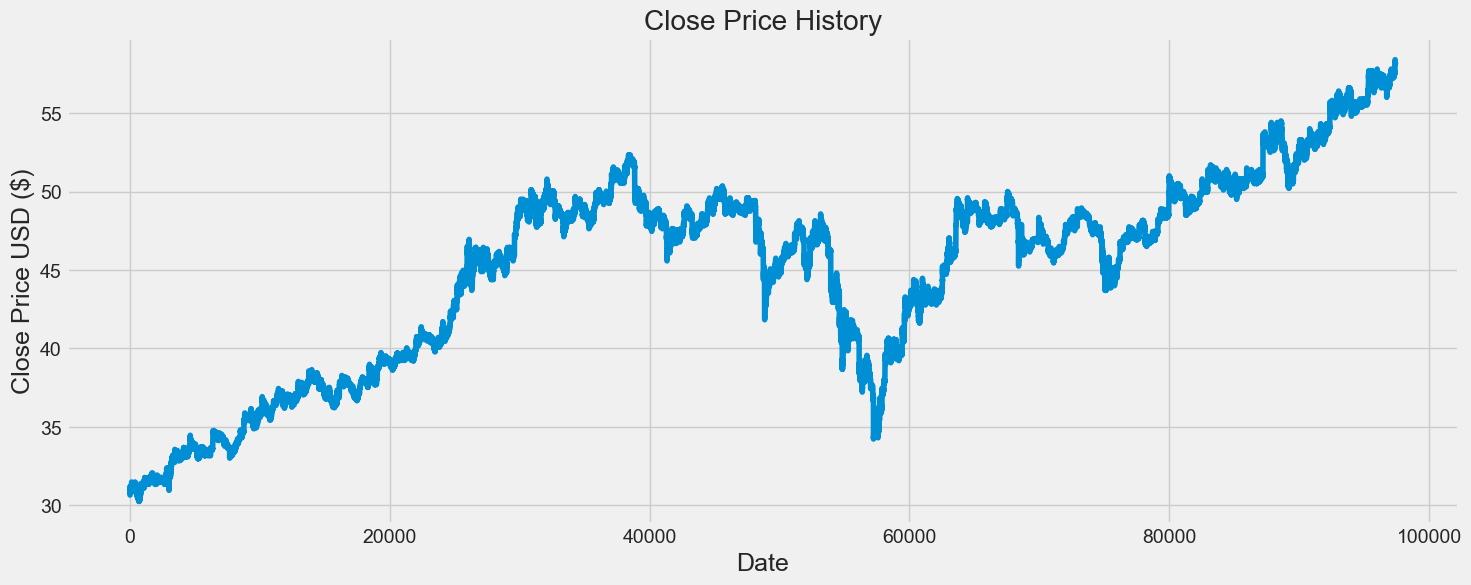

In [8]:
plt.figure(figsize=(16,6))
plt.title('Close Price History')
plt.plot(df['Close'])
plt.xlabel('Date', fontsize=18)
plt.ylabel('Close Price USD ($)', fontsize=18)
plt.show()

# Tiền xử lý dữ liệu

+ Lấy trung bình dữ liệu theo giờ để làm phẳng data và dễ dàng fill những data còn thiếu

In [9]:
df.set_index('Date/Time', inplace=True)

df = df.resample('H').mean()

In [10]:
df.describe()

,Open,High,Low,Close,Volume
count,2491.000000,2491.000000,2491.000000,2491.000000,2491.000000
mean,44.366750,44.384065,44.347765,44.366655,7832.670001
std,6.745292,6.751114,6.738897,6.745224,7015.397652
min,30.316757,30.319730,30.309459,30.314324,546.190476
25%,38.185003,38.193263,38.168887,38.179242,3789.794872
50%,46.527083,46.542456,46.510417,46.522917,5933.508772
75%,49.027188,49.039769,49.005285,49.026936,9550.717723
max,58.186207,58.227586,58.165517,58.189655,106245.161290


In [11]:
df.isnull().sum()

Open      14987
High      14987
Low       14987
Close     14987
Volume    14987
dtype: int64

+ Lấp vào những data còn thiếu để có thể sử dụng các model time-series

In [12]:
df.interpolate(method='linear', inplace=True)  
df.ffill(inplace=True) 

In [13]:
df.isnull().sum()

Open      0
High      0
Low       0
Close     0
Volume    0
dtype: int64

+ Chia data thành tập dự đoán và tập dữ liệu dùng để dự đoán để dễ dàng inverse scale

In [14]:
df_X = df.reset_index()[['Open', 'High', 'Low', 'Close', 'Volume']]


In [15]:
df_X

,Open,High,Low,Close,Volume
0,30.760000,30.781429,30.744286,30.760000,12137.142857
1,30.772321,30.793259,30.756920,30.772381,11705.758929
2,30.784643,30.805089,30.769554,30.784762,11274.375000
3,30.796964,30.816920,30.782187,30.797143,10842.991071
4,30.809286,30.828750,30.794821,30.809524,10411.607143
...,...,...,...,...,...
17473,57.393333,57.413333,57.368333,57.393333,5966.833333
17474,57.507143,57.532143,57.471429,57.507143,12836.428571
17475,57.567460,57.592923,57.537566,57.568386,14666.825397
17476,57.627778,57.653704,57.603704,57.629630,16497.222222


+ Data được dùng để dự đoán sẽ là data close sau time step sử dụng dữ liệu của các time-step trước đó

In [16]:
df_y = df.reset_index()['Close']

In [17]:
df_y

0        30.760000
1        30.772381
2        30.784762
3        30.797143
4        30.809524
           ...    
17473    57.393333
17474    57.507143
17475    57.568386
17476    57.629630
17477    58.189655
Name: Close, Length: 17478, dtype: float64

+ Mô hình được chọn là LSTM, vì nó có khả năng làm việc với dữ liệu trong theo thời gian rất tốt. Ngoài ra chúng ta còn có thể chọn ARIMA, tuy nhiên với dataset lớn và phức tạp như giá cổ phiếu, ARIMA sẽ không hoạt động tốt. Vì LSTM rất nhạy cảm với quy mô dữ liệu, chúng ta sẽ sử dụng MinMaxScaler.

+ Chúng ta phải chia thành 2 scaler ( một cho tập dữ liệu đầu vào và 1 tập dữ liệu đầu ra ) để có thể inverse scale mà không bị lỗi chiều dữ liệu

In [18]:
scaler1 = MinMaxScaler(feature_range=(0,4))   
df_X = scaler1.fit_transform(np.array(df_X).reshape(-1, 5))

In [19]:
scaler2 = MinMaxScaler(feature_range=(0,1))   
df_y = scaler2.fit_transform(np.array(df_y).reshape(-1, 1))

In [20]:
df_X

array([[0.06361708, 0.06617475, 0.06243902, 0.0639527 , 0.43864012],
       [0.06538553, 0.06787038, 0.0642532 , 0.06572932, 0.42231512],
       [0.06715398, 0.06956601, 0.06606737, 0.06750594, 0.40599012],
       ...,
       [3.91119357, 3.90903451, 3.90982915, 3.91085036, 0.53437171],
       [3.91985072, 3.9177461 , 3.9193262 , 3.91963854, 0.60364   ],
       [4.        , 4.        , 4.        , 4.        , 0.79866432]])

In [21]:
df_y

array([[0.01598818],
       [0.01643233],
       [0.01687648],
       ...,
       [0.97771259],
       [0.97990964],
       [1.        ]])

In [22]:
data = np.concatenate([df_X, df_y], axis=1)

In [23]:
data

array([[0.06361708, 0.06617475, 0.06243902, 0.0639527 , 0.43864012,
        0.01598818],
       [0.06538553, 0.06787038, 0.0642532 , 0.06572932, 0.42231512,
        0.01643233],
       [0.06715398, 0.06956601, 0.06606737, 0.06750594, 0.40599012,
        0.01687648],
       ...,
       [3.91119357, 3.90903451, 3.90982915, 3.91085036, 0.53437171,
        0.97771259],
       [3.91985072, 3.9177461 , 3.9193262 , 3.91963854, 0.60364   ,
        0.97990964],
       [4.        , 4.        , 4.        , 4.        , 0.79866432,
        1.        ]])

+ Tạo dataset để train time-series model

In [24]:
training_size = int(len(data)*0.75)
test_size = len(data) - training_size
train_data_X = df_X[:training_size, :]
test_data_X = df_X[training_size:, :]
train_data_y = df_y[:training_size, :]
test_data_y = df_y[training_size:, :]

In [25]:
train_data_X.shape, test_data_X.shape

((13108, 5), (4370, 5))

In [26]:
def create_dataset(df_x, df_y, time_step=1):
    dataX, dataY = [], []
    for i in range(len(df_y) - time_step - 1):
        a = df_x[i:(i + time_step), :]
        dataX.append(a)
        dataY.append(df_y[i + time_step, -1])
    return np.array(dataX), np.array(dataY)

In [27]:
time_step = 100,
X_train, y_train = create_dataset(train_data_X, train_data_y, time_step[0])
X_test, y_test = create_dataset(test_data_X, test_data_y, time_step[0])

In [28]:
y_train = y_train.reshape(-1,1 )
y_test = y_test.reshape(-1,1 )

In [29]:
X_train 

array([[[0.06361708, 0.06617475, 0.06243902, 0.0639527 , 0.43864012],
        [0.06538553, 0.06787038, 0.0642532 , 0.06572932, 0.42231512],
        [0.06715398, 0.06956601, 0.06606737, 0.06750594, 0.40599012],
        ...,
        [0.15760725, 0.15834466, 0.15773527, 0.15788892, 0.29849624],
        [0.1575381 , 0.15827296, 0.15767015, 0.15782884, 0.2966729 ],
        [0.15746895, 0.15820125, 0.15760503, 0.15776876, 0.29484957]],

       [[0.06538553, 0.06787038, 0.0642532 , 0.06572932, 0.42231512],
        [0.06715398, 0.06956601, 0.06606737, 0.06750594, 0.40599012],
        [0.06892243, 0.07126164, 0.06788154, 0.06928255, 0.38966512],
        ...,
        [0.1575381 , 0.15827296, 0.15767015, 0.15782884, 0.2966729 ],
        [0.15746895, 0.15820125, 0.15760503, 0.15776876, 0.29484957],
        [0.15739979, 0.15812955, 0.15753991, 0.15770867, 0.29302623]],

       [[0.06715398, 0.06956601, 0.06606737, 0.06750594, 0.40599012],
        [0.06892243, 0.07126164, 0.06788154, 0.06928255, 0.3

In [30]:
y_train

array([[0.03942717],
       [0.03941215],
       [0.03939713],
       ...,
       [0.59562047],
       [0.61226293],
       [0.63221405]])

In [31]:
X_test.shape, y_test.shape

((4269, 100, 5), (4269, 1))

In [32]:
print(X_train.shape), print(y_train.shape)
print(X_test.shape), print(y_test.shape)

(13007, 100, 5)
(13007, 1)
(4269, 100, 5)
(4269, 1)


(None, None)

# Tạo model Stacked LSTM

30 30 30 0.3 0.01 100 epochs

In [34]:
model = tf.keras.models.Sequential([
    tf.keras.layers.LSTM(40, return_sequences=True, input_shape=(time_step[0], 5)),
    tf.keras.layers.Dropout(0.3),  
    
    tf.keras.layers.LSTM(40, return_sequences=True),
    tf.keras.layers.Dropout(0.3),  
    
    tf.keras.layers.LSTM(40),
    tf.keras.layers.Dropout(0.3),  
    
    tf.keras.layers.Dense(1)
])
model.compile(optimizer='adam', loss='mean_squared_error')


c:\Users\phana\anaconda3\Lib\site-packages\keras\src\layers\rnn\rnn.py:204: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


In [35]:
train_dataset = tf.data.Dataset.from_tensor_slices((X_train, y_train))
test_dataset = tf.data.Dataset.from_tensor_slices((X_test, y_test))

batch_size = 64
train_dataset = train_dataset.batch(batch_size).repeat()  
test_dataset = test_dataset.batch(batch_size)

+ Chọn số vòng lặp = 100 vì sau khi đánh giá model ta thấy từ sau vòng lặp 100 lỗi của mô hình sẽ tăng dần.

In [36]:
history = ( 
    model.fit(train_dataset, 
          validation_data=(X_test,y_test), 
          epochs=100, 
          steps_per_epoch=len(X_train) // batch_size, 
          verbose=1)
)

Epoch 1/100
203/203 ━━━━━━━━━━━━━━━━━━━━ 27s 96ms/step - loss: 0.0033 - val_loss: 0.0359
Epoch 2/100
203/203 ━━━━━━━━━━━━━━━━━━━━ 20s 98ms/step - loss: 0.0143 - val_loss: 0.0160
Epoch 3/100
203/203 ━━━━━━━━━━━━━━━━━━━━ 18s 88ms/step - loss: 0.0088 - val_loss: 0.0154
Epoch 4/100
203/203 ━━━━━━━━━━━━━━━━━━━━ 17s 84ms/step - loss: 0.0051 - val_loss: 0.0172
Epoch 5/100
203/203 ━━━━━━━━━━━━━━━━━━━━ 17s 86ms/step - loss: 0.0025 - val_loss: 0.0170
Epoch 6/100
203/203 ━━━━━━━━━━━━━━━━━━━━ 18s 86ms/step - loss: 0.0029 - val_loss: 0.0179
Epoch 7/100
203/203 ━━━━━━━━━━━━━━━━━━━━ 18s 86ms/step - loss: 0.0025 - val_loss: 0.0182
Epoch 8/100
203/203 ━━━━━━━━━━━━━━━━━━━━ 17s 84ms/step - loss: 0.0021 - val_loss: 0.0180
Epoch 9/100
203/203 ━━━━━━━━━━━━━━━━━━━━ 17s 85ms/step - loss: 0.0022 - val_loss: 0.0198
Epoch 10/100
203/203 ━━━━━━━━━━━━━━━━━━━━ 17s 85ms/step - loss: 0.0021 - val_loss: 0.0185
Epoch 11/100
203/203 ━━━━━━━━━━━━━━━━━━━━ 17s 85ms/step - loss: 0.0020 - val_loss: 0.0220
Epoch 12/100
203/20

# Đánh giá model

+ Chúng ta cần xét loss của model qua mỗi epoch để có thể dừng train sớm, giảm thiểu tối đa loss

In [37]:
def plot_loss(history):
  plt.plot(history.history['loss'], label='loss')
  plt.plot(history.history['val_loss'], label='val_loss')
  plt.xlabel('Epoch')
  plt.ylabel('MSE')
  plt.legend()
  plt.grid(True)
  plt.show()

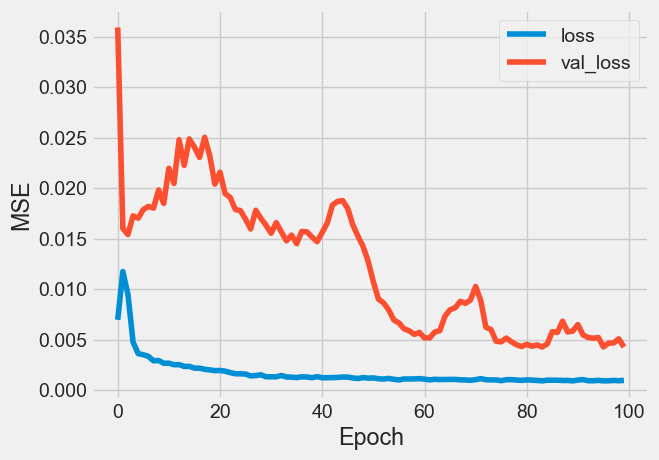

In [38]:
plot_loss(history)

+ Tiếp theo chúng ta cần đánh giá độ chính xác của dự đoán

In [39]:
predictions_scaled = model.predict(X_test)
predictions_scaled = predictions_scaled.reshape(-1,1)

predictions_train = model.predict(X_train)  
predictions_train = predictions_train.reshape(-1,1)

134/134 ━━━━━━━━━━━━━━━━━━━━ 3s 19ms/step
407/407 ━━━━━━━━━━━━━━━━━━━━ 6s 14ms/step


In [40]:
predictions = scaler2.inverse_transform(predictions_scaled)
predictions_train = scaler2.inverse_transform(predictions_train)
y_test = scaler2.inverse_transform(y_test)
y_train = scaler2.inverse_transform(y_train)

In [41]:
column_names_pred = ['Close_predict']
df_predictions = pd.DataFrame(predictions, columns=column_names_pred)

df_test = pd.DataFrame(y_test)

In [42]:
df_predictions

,Close_predict
0,47.615353
1,47.610497
2,47.605629
3,47.600754
4,47.595882
...,...
4264,52.523228
4265,52.523315
4266,52.524750
4267,52.519524


In [43]:
df_test

,0
0,46.585025
1,46.577927
2,46.570829
3,46.563731
4,46.556633
...,...
4264,57.453333
4265,57.393333
4266,57.507143
4267,57.568386


In [44]:
concatenated = np.concatenate([df_predictions, df_test], axis=1)
column_names_concat = ['Close_predict', 'Close_test']
df_concatenated = pd.DataFrame(concatenated, columns = column_names_concat)

df_test.reset_index(drop=True, inplace=True)

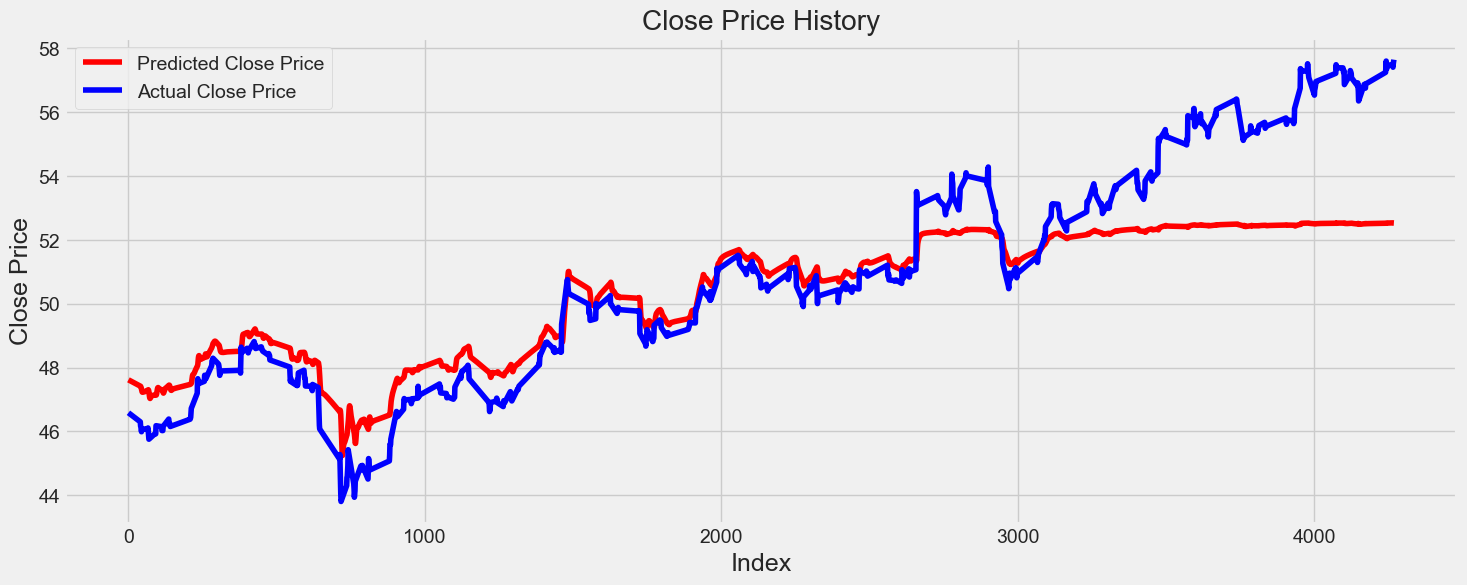

In [ ]:
plt.figure(figsize=(16,6))
plt.title('Close Price History')
plt.plot(df_predictions['Close_predict'], color='red', label='Predicted Close Price')
plt.plot(df_test, color='blue', label='Actual Close Price')
plt.legend()
plt.xlabel('Index', fontsize=18)
plt.ylabel('Close Price', fontsize=18)
plt.show()

+ Đánh giá độ hiệu quả của mô hình bằng các metrics

In [46]:
mae_train = mean_absolute_error(y_train, predictions_train)
rmse_train = mean_squared_error(y_train, predictions_train)
r2_train = r2_score(y_train, predictions_train)

print("Train Mean Absolute Error:", mae_train)
print("Train Mean Squared Error:", rmse_train)
print("Train R-squared:", r2_train)

Train Mean Absolute Error: 1.0664633984997964
Train Mean Squared Error: 1.6038274174204998
Train R-squared: 0.9580161496220656


In [47]:
mae_test = mean_absolute_error(y_test, predictions)
rmse_test = mean_squared_error(y_test, predictions)
r2_test = r2_score(y_test, predictions)

print("Test Mean Absolute Error:", mae_test)
print("Test Mean Squared Error:", rmse_test)
print("Test R-squared:", r2_test)

Test Mean Absolute Error: 1.298874137680066
Test Mean Squared Error: 3.305836902452931
Test R-squared: 0.7297598286847063


# Dự đoán

In [48]:
len(test_data_X)

4370

In [49]:
demo_test = test_data_X

In [50]:
x_input = demo_test[-(time_step[0]):]

In [51]:
x_input

array([[3.80001762, 3.79743332, 3.79827685, 3.79905251, 0.13046034],
       [3.79607595, 3.79369123, 3.79478423, 3.79549161, 0.16268029],
       [3.79213428, 3.78994915, 3.79129161, 3.79193072, 0.19490025],
       [3.81061123, 3.80732983, 3.81061921, 3.81063469, 0.38410249],
       [3.81140622, 3.80812135, 3.81141458, 3.81141285, 0.38549259],
       [3.81220121, 3.80891286, 3.81220995, 3.81219101, 0.38688269],
       [3.81299619, 3.80970438, 3.81300532, 3.81296918, 0.38827279],
       [3.81379118, 3.8104959 , 3.81380069, 3.81374734, 0.38966289],
       [3.81458617, 3.81128742, 3.81459606, 3.8145255 , 0.39105299],
       [3.81538116, 3.81207893, 3.81539143, 3.81530367, 0.39244308],
       [3.81617615, 3.81287045, 3.8161868 , 3.81608183, 0.39383318],
       [3.81697114, 3.81366197, 3.81698217, 3.81685999, 0.39522328],
       [3.81776612, 3.81445348, 3.81777754, 3.81763815, 0.39661338],
       [3.81856111, 3.815245  , 3.81857291, 3.81841632, 0.39800348],
       [3.8193561 , 3.81603652, 3.

In [52]:
x_input = x_input.reshape(time_step[0], 5)

In [53]:
x_input.shape

(100, 5)

+ Tạo ra một dữ liệu test tạm thời

In [54]:
temp_input = list(x_input) 

In [55]:
temp_input_lists = [arr.tolist() for arr in temp_input]

In [56]:
temp_input 

[array([3.80001762, 3.79743332, 3.79827685, 3.79905251, 0.13046034]),
 array([3.79607595, 3.79369123, 3.79478423, 3.79549161, 0.16268029]),
 array([3.79213428, 3.78994915, 3.79129161, 3.79193072, 0.19490025]),
 array([3.81061123, 3.80732983, 3.81061921, 3.81063469, 0.38410249]),
 array([3.81140622, 3.80812135, 3.81141458, 3.81141285, 0.38549259]),
 array([3.81220121, 3.80891286, 3.81220995, 3.81219101, 0.38688269]),
 array([3.81299619, 3.80970438, 3.81300532, 3.81296918, 0.38827279]),
 array([3.81379118, 3.8104959 , 3.81380069, 3.81374734, 0.38966289]),
 array([3.81458617, 3.81128742, 3.81459606, 3.8145255 , 0.39105299]),
 array([3.81538116, 3.81207893, 3.81539143, 3.81530367, 0.39244308]),
 array([3.81617615, 3.81287045, 3.8161868 , 3.81608183, 0.39383318]),
 array([3.81697114, 3.81366197, 3.81698217, 3.81685999, 0.39522328]),
 array([3.81776612, 3.81445348, 3.81777754, 3.81763815, 0.39661338]),
 array([3.81856111, 3.815245  , 3.81857291, 3.81841632, 0.39800348]),
 array([3.8193561 , 

In [57]:
temp_input = np.array(temp_input)
temp_input.shape

(100, 5)

+ Đưa ra dự đoán cho 24 giờ tiếp theo

In [58]:
def predict_next_24_steps(model, initial_input, n_steps=24):
    predictions = []
    current_input = initial_input.copy() 

    for i in range(n_steps-1):
        if len(current_input.shape) == 2:
            current_input_reshaped = current_input.reshape(1, current_input.shape[0], current_input.shape[1])
        else:
            raise ValueError("current_input must be a 2D array with shape (time_steps, features)")
        
        next_step_prediction = model.predict(current_input_reshaped)[0, 0] 
        
        predictions.append(next_step_prediction)
        
        current_input = np.append(current_input[1:], [[next_step_prediction] + [0]*(current_input.shape[1]-1)], axis=0)

    return predictions

In [66]:
stocks = predict_next_24_steps(model, temp_input)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 24ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 24ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 25ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 31ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 24ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step


In [67]:
stocks

[0.7963445,
 0.78302485,
 0.6914582,
 0.6213982,
 0.56105345,
 0.52873445,
 0.514423,
 0.5086859,
 0.5049941,
 0.5008397,
 0.49650726,
 0.49280745,
 0.49006984,
 0.48809484,
 0.4864556,
 0.48486745,
 0.48333746,
 0.48204142,
 0.4811408,
 0.48069313,
 0.4806552,
 0.48092481,
 0.48138347]

In [68]:
print('Biến động cổ phiếu trong 24h tới:')
for i in stocks:
    a = scaler2.inverse_transform(i.reshape(-1, 1))
    print(a - df['Close'][-1])

Biến động cổ phiếu trong 24h tới:
[[-5.676964]]
[[-6.048256]]
[[-8.600704]]
[[-10.55365]]
[[-12.235783]]
[[-13.136681]]
[[-13.535618]]
[[-13.695545]]
[[-13.798454]]
[[-13.914257]]
[[-14.03503]]
[[-14.138161]]
[[-14.214474]]
[[-14.269527]]
[[-14.31522]]
[[-14.359489]]
[[-14.402142]]
[[-14.438267]]
[[-14.463371]]
[[-14.475849]]
[[-14.476906]]
[[-14.469395]]
[[-14.456608]]
